<a href="https://colab.research.google.com/github/FelipeaACamargo/clusterizacao-clientes-supermercado/blob/main/Segmentacao_Clientes_Shopping_KMeans_Hierarquico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Clusterização de Clientes de um Shopping de Supermercado

**Problema:** Você é proprietário de um shopping de supermercado e deseja entender melhor o perfil dos seus clientes para potencializar o sucesso das estratégias de *marketing*. Para isso, dispõe de dados coletados pelo cartão de membro, que incluem informações como gênero, idade, renda anual e uma pontuação que reflete o nível de gastos de cada cliente no shopping.

**Objetivo:** Analisar o comportamento desses clientes e segmentá-los em grupos (clusters) com características semelhantes, utilizando técnicas de análise de agrupamento (clustering). Essa segmentação permite identificar, por exemplo, clientes com alta propensão de gastos, jovens com baixo engajamento ou grupos sensíveis a promoções, entre outros perfis possíveis.

Com os resultados, é possível direcionar campanhas e ações personalizadas para cada segmento identificado — aumentando a eficiência do *marketing*, melhorando o relacionamento com os clientes e apoiando decisões estratégicas para maximizar a satisfação e a rentabilidade do shopping.


---


**Banco de Dados:** Mall Customers
Contém informações de 200 clientes. Você é dono de um shopping de supermercado e, por meio de cartões de membro, tem alguns dados básicos sobre seus clientes, como:

- ID do cliente (CustomerID).
- Gênero (Gender).
- Idade (Age).
- Renda Anual (mil dólares) (Annual Income (k$)).
- Pontuação de gasto no shopping (Spending Score (1-100)).


A pontuação de gastos é algo que você atribui ao cliente com base em seus parâmetros definidos, como comportamento do cliente e dados de compra.


---


Link: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

# 1. Importação das Bibliotecas

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

# 2. Importando o arquivo do site Kaggle


In [ ]:
import kagglehub

# Baixar a versão mais recente do dataset
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path) # Mostra o caminho da pasta onde os arquivos foram salvos

Path to dataset files: /root/.cache/kagglehub/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/versions/1


# 3. Carregar o Banco de Dados
Usaremos **pandas** para ler o arquivo csv.

Analisaremos as primeiras linhas para entender as colunas e os tipos de dados.

In [ ]:
# Seu caminho recebido do kagglehub
# path = '/root/.cache/kagglehub/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/versions/1'

# Carregue o arquivo CSV do dataset
data = pd.read_csv(path + '/Mall_Customers.csv')
display(data.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 4. Análise Exploratória de Dados

**Estatísticas básicas:** O comando *describe( )* calcula as estatísticas descritivas para cada coluna numérica no conjunto de dados. Ele fornece:

- **Contagem:** número de valores não nulos.
- **Média:** a média aritmética dos valores.
- **Desvio Padrão:** a medida de dispersão dos dados.
- **Mínimo e Máximo:** os valores mais baixos e mais altos.
- **Quartis (25%, 50% e 75%):** os percentis que dividem os dados em 4 partes.

**Obs.:** As estatísticas básicas são úteis para verificar rapidamente a distribuição e a variação dos dados, identificar a presença de valores extremos (*outliers*) e compreender o comportamento geral das variáveis.


In [ ]:
# Estatísticas descritivas
print("\nEstatísticas Básicas:\n")
display(data.describe())


Estatísticas Básicas:



,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# 5. Histograma

O histograma mostra a distribuição de cada variável (como Idade, Renda Anual (mil dólares) e Pontuação de Gastos). Cada barra representa o número de ocorrências dentro de um intervalo de valores, permitindo ver como os dados se distribuem.

- Identificar a forma da distribuição (normal, enviesada, uniforme, etc.).
- Detectar a presença de outliers ou valores extremos.
- Compreender a densidade dos dados em diferentes intervalos.
  * Por exemplo, se a variável Renda Anual tiver um pico na parte inferior, pode significar que a maioria dos clientes tem uma renda mais baixa.
  * Se a Pontuação de Gastos for mais concentrada em torno de um valor médio, isso indica que os clientes tendem a gastar de maneira semelhante.

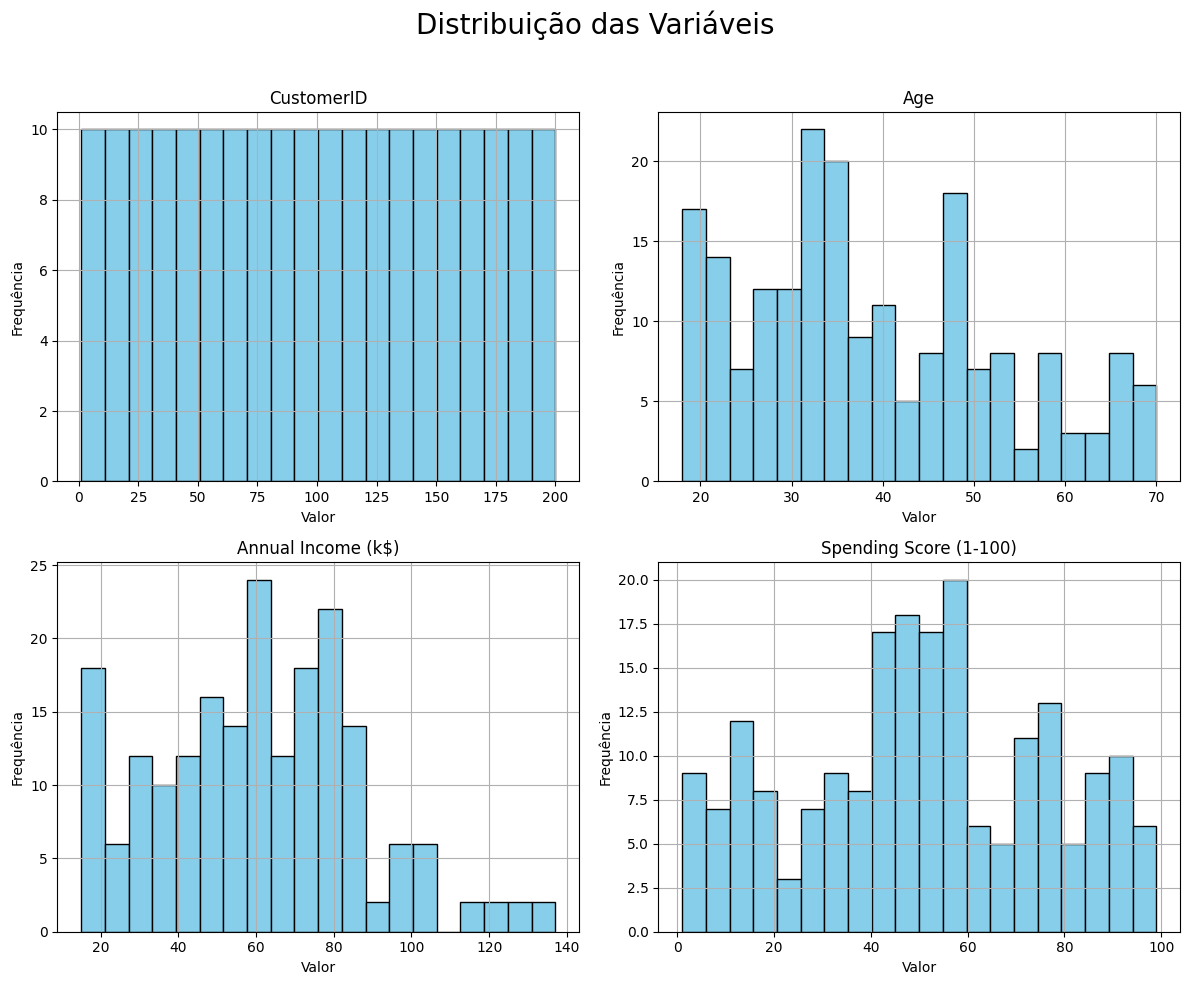

In [ ]:
axes = data.hist(bins=20, figsize=(12, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distribuição das Variáveis', fontsize=20)

# Adiciona labels para cada subplot
for ax in axes.flatten():
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Ajusta layout para não sobrepor o título
plt.show()

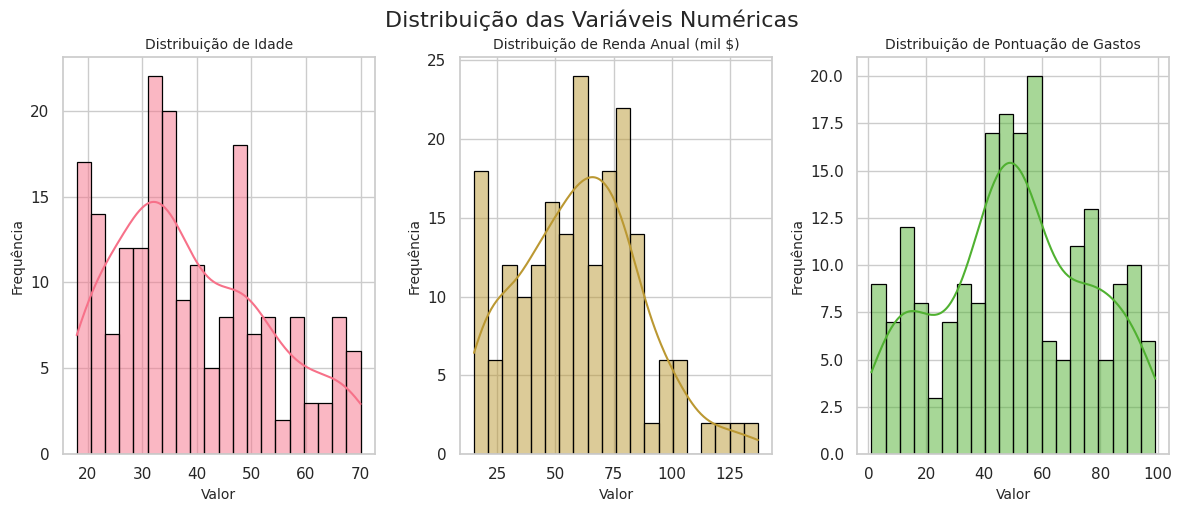

In [ ]:
# Gráfico mais detalhado/estilizado
sns.set(style = "whitegrid") # whitegrid, darkgrid, white, dark e ticks

# Criando histogramas detalhados
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
axes = axes.flatten()

# Tradução dos nomes das variáveis
traducao_variaveis = {
    'Age': 'Idade',
    'Annual Income (k$)': 'Renda Anual (mil $)',
    'Spending Score (1-100)': 'Pontuação de Gastos'
}

# Variáveis numéricas
variaveis_numericas = data.select_dtypes(include=['float', 'int']).columns

# Iterando para criar os histogramas, pulando a primeira variável
for i, coluna in enumerate(variaveis_numericas):
    if i == 0:  # Pula a primeira variável
        continue
    sns.histplot(data[coluna], bins = 20, kde = True, color = sns.color_palette("husl")[(i-1) % 6], ax=axes[i-1], edgecolor='black')
    # Usando o nome traduzido no título
    axes[i-1].set_title(f'Distribuição de {traducao_variaveis.get(coluna, coluna)}', fontsize=10)
    axes[i-1].set_xlabel('Valor', fontsize=10)
    axes[i-1].set_ylabel('Frequência', fontsize=10)

# Ajustar o layout
plt.tight_layout()
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=16, y=1.02)
plt.show()

# 6. Boxplot
O boxplot mostra a distribuição das variáveis, incluindo:

Mediana: a linha no meio da caixa.

Quartis: os limites superior e inferior da caixa.

Bigodes: as linhas que se estendem para fora da caixa, representando os valores máximos e mínimos dentro de um intervalo aceitável.

Outliers: pontos fora dos bigodes, representando valores atípicos.

Importância:

Ajudar a identificar outliers (valores que estão distantes da maioria dos dados), que podem afetar análises posteriores.

Compreender a dispersão e a assimetria dos dados (se a caixa está mais para um lado do que para o outro).

Por exemplo, se a variável Idade tiver um outlier acima de 100 anos, é importante investigar se esse dado é correto ou se é um erro de entrada.


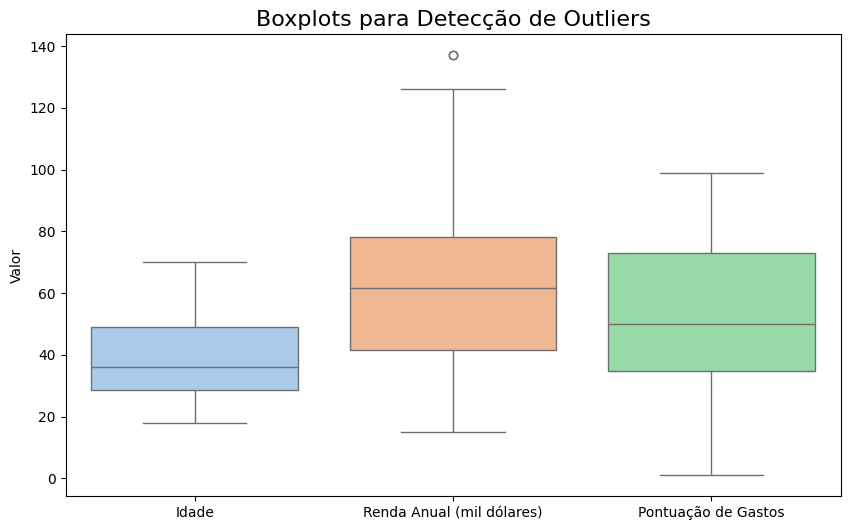

In [ ]:
# Boxplots para variáveis numéricas
plt.figure(figsize=(10, 6))
sns.boxplot(data=data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']], palette="pastel")
plt.title('Boxplots para Detecção de Outliers', fontsize=16)
plt.xticks(ticks=[0, 1, 2], labels=['Idade', 'Renda Anual (mil dólares)', 'Pontuação de Gastos'])
plt.ylabel('Valor')
plt.show()

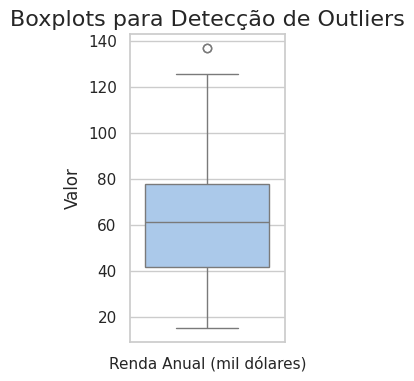

In [ ]:
# Boxplots para variáveis numéricas
plt.figure(figsize=(2, 4))
sns.boxplot(data = data[['Annual Income (k$)']], palette="pastel")
plt.title('Boxplots para Detecção de Outliers', fontsize=16)
plt.xticks(ticks=[0], labels=['Renda Anual (mil dólares)'])
plt.ylabel('Valor')
plt.show()

/tmp/ipython-input-2318742239.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Annual Income (k$)', data=data, palette="pastel")


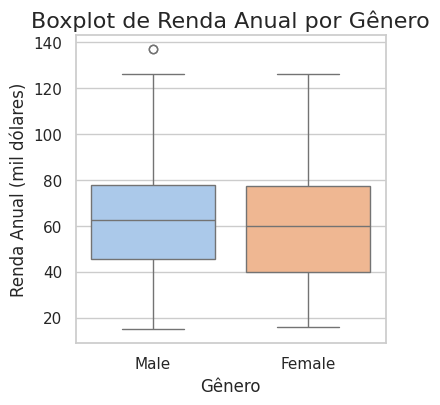

In [ ]:
# Boxplot para comparar 'Renda Anual' por 'Gênero'
plt.figure(figsize=(4, 4))
sns.boxplot(x='Gender', y='Annual Income (k$)', data=data, palette="pastel")
plt.title('Boxplot de Renda Anual por Gênero', fontsize=16)
plt.xlabel('Gênero')
plt.ylabel('Renda Anual (mil dólares)')
plt.show()

# 7. Gráfico de Barras - Relação de Gênero com Renda e Gastos

Este gráfico de barras mostra a média de Renda Anual e Pontuação de Gastos para cada Gênero. Cada barra representa a média de uma variável (renda ou gastos) para os clientes masculinos e femininos.

Importância:

Comparar o comportamento de gastos e renda entre os gêneros.
Verificar se há uma diferença significativa entre os grupos, o que pode ajudar a personalizar estratégias de marketing ou segmentação de clientes.
Por exemplo, se os homens têm uma renda anual média mais alta, mas uma pontuação de gastos mais baixa do que as mulheres, pode ser relevante para entender as preferências de compra dos diferentes grupos.


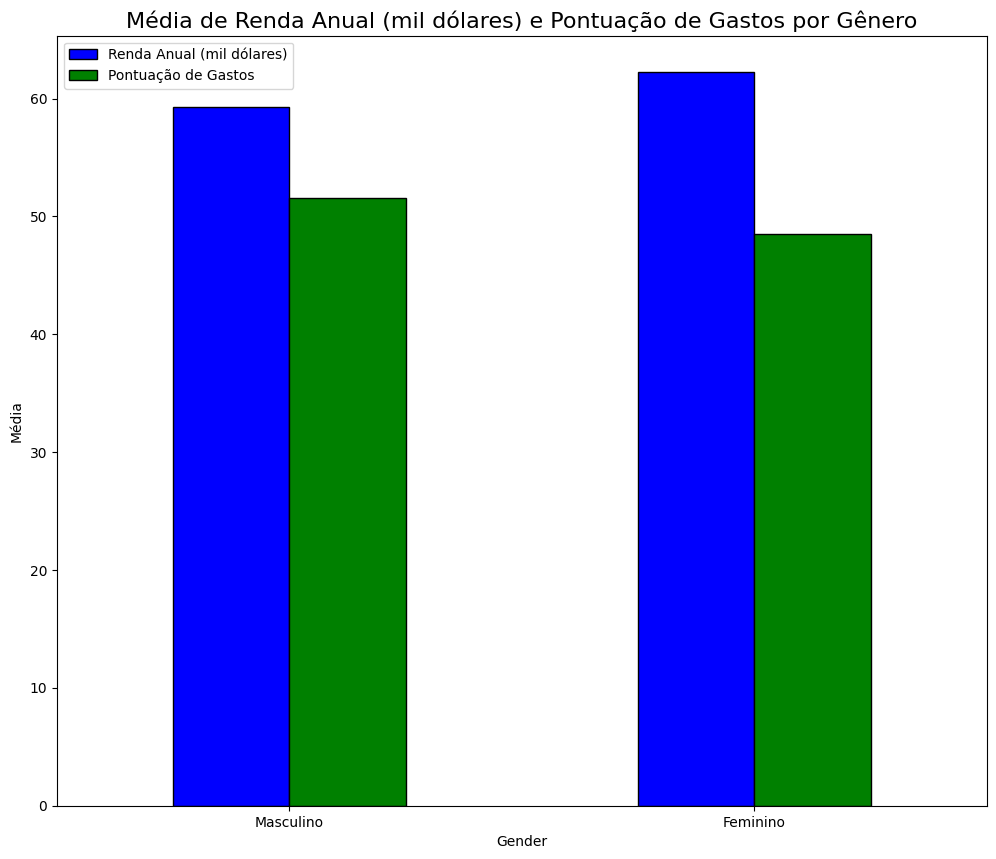

In [ ]:
# Média de Renda Anual e Pontuação de Gastos por Gênero
gender_analysis = data.groupby('Gender')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

# Gráfico de Barras
gender_analysis.plot(kind='bar', figsize=(12, 10), color=['blue', 'green'], edgecolor='black')
plt.title('Média de Renda Anual (mil dólares) e Pontuação de Gastos por Gênero', fontsize=16)
plt.ylabel('Média')
plt.xticks(ticks=[0, 1], labels=['Masculino', 'Feminino'], rotation=0)
plt.legend(['Renda Anual (mil dólares)', 'Pontuação de Gastos'])
plt.show()

# 8. Gráfico de Dispersão - Relação Entre Variáveis
O scatter plot (ou gráfico de dispersão) exibe a relação entre duas variáveis numéricas. Aqui, comparamos Renda Anual com Pontuação de Gastos. Se quisermos podemos usar cores para distinguir o Gênero (masculino/feminino).

Importância:

Verificar relações ou correlações entre as variáveis (por exemplo, se clientes com maior renda tendem a gastar mais).
Identificar padrões ou tendências.
Observar se há agrupamentos (clusters) naturais de pontos, o que pode ser útil para segmentação de clientes.
Compreender como o gênero afeta as variáveis de renda e gastos.


/tmp/ipython-input-3837012439.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',  data=data, palette="coolwarm") # hue='Gender',


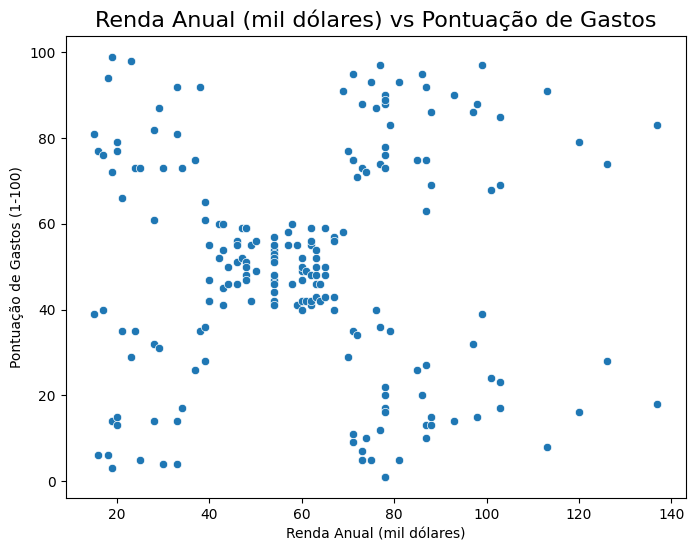

In [ ]:
# Scatter plot para Renda Anual vs. Pontuação de Gastos
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',  data=data, palette="coolwarm") # hue='Gender',
plt.title('Renda Anual (mil dólares) vs Pontuação de Gastos', fontsize=16)
plt.xlabel('Renda Anual (mil dólares)')
plt.ylabel('Pontuação de Gastos (1-100)')
# plt.legend(title='Gênero', labels=['Feminino', 'Masculino'])
plt.show()

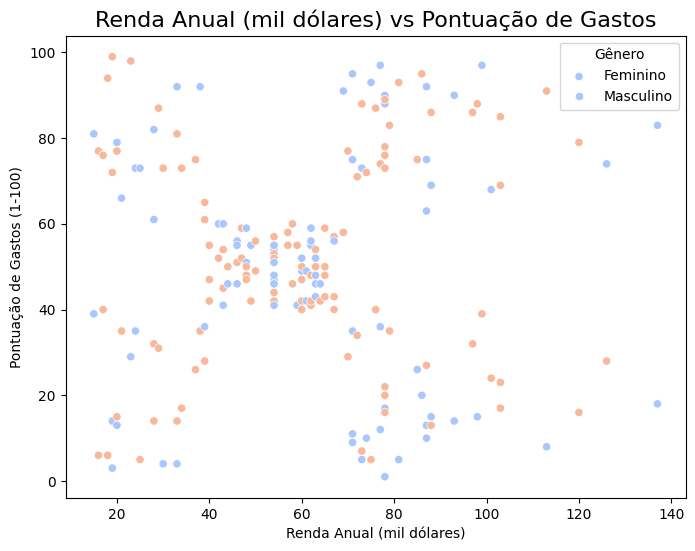

In [ ]:
# Scatter plot para Renda Anual vs. Pontuação de Gastos
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gender',  data=data, palette="coolwarm")
plt.title('Renda Anual (mil dólares) vs Pontuação de Gastos', fontsize=16)
plt.xlabel('Renda Anual (mil dólares)')
plt.ylabel('Pontuação de Gastos (1-100)')
plt.legend(title='Gênero', labels=['Feminino', 'Masculino'])
plt.show()

# 9. Pré-processar os dados:
Normalizar as colunas "Renda Anual" e "Pontuação de Gasto".

Desconsiderar colunas categóricas, como "Gênero", para este exercício.



In [ ]:
# Selecionar colunas para clusterização
data_filtered = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Normalizar os dados
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_filtered)


# 10. Agrupamento com K-Means
Usar a biblioteca sklearn para aplicar k-means (from sklearn.cluster import KMeans).

Determinar o número ideal de clusters (método do cotovelo ou silhouette).

Realizar a clusterização e analisar os resultados.



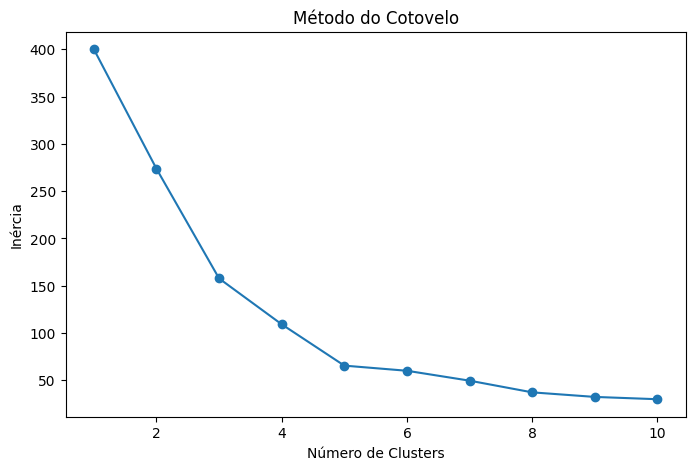

In [ ]:
# K-Means: Determinar o número de clusters (método do cotovelo)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# Plotar o método do cotovelo
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inércia")
plt.show()

Silhouette Score para K-Means: 0.55


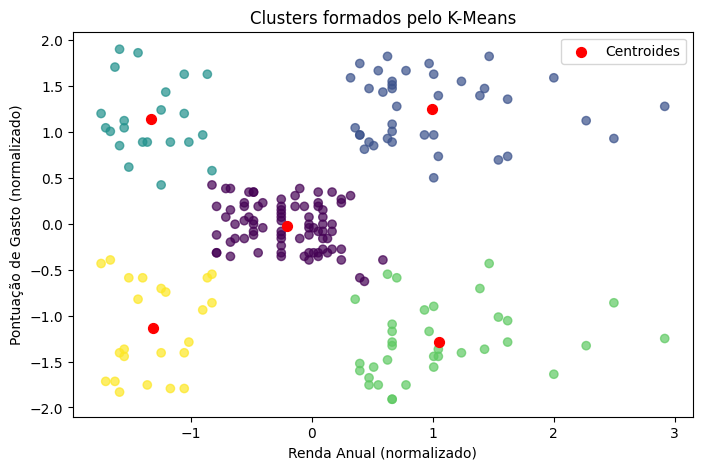

In [ ]:
# Aplicar K-Means com o número ideal de clusters
kmeans = KMeans(n_clusters = 5, random_state=42)
labels_kmeans = kmeans.fit_predict(data_scaled)
silhouette_kmeans = silhouette_score(data_scaled, labels_kmeans)

print(f"Silhouette Score para K-Means: {silhouette_kmeans:.2f}")

# Visualizar os clusters formados pelo k-means
plt.figure(figsize=(8, 5))
plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=50, c='red', label='Centroides')
plt.title("Clusters formados pelo K-Means")
plt.xlabel("Renda Anual (normalizado)")
plt.ylabel("Pontuação de Gasto (normalizado)")
plt.legend()

# 10. Agrupamento Hierárquico
Usar a biblioteca scipy ou sklearn para aplicar o algoritmo de clustering hierárquico.

Usar a técnica de linkage (método Ward).

Visualizar os resultados em um dendrograma.


In [ ]:
# Agrupamento Hierárquico
linkage_matrix = linkage(data_scaled, method = 'ward', metric = 'euclidean')


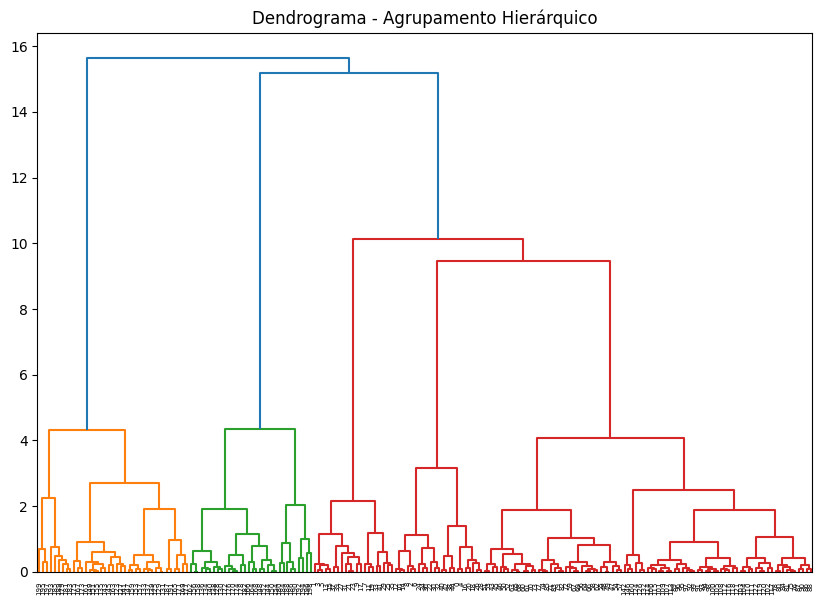

In [ ]:
# Visualizar Dendrograma
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title('Dendrograma - Agrupamento Hierárquico')
plt.show()

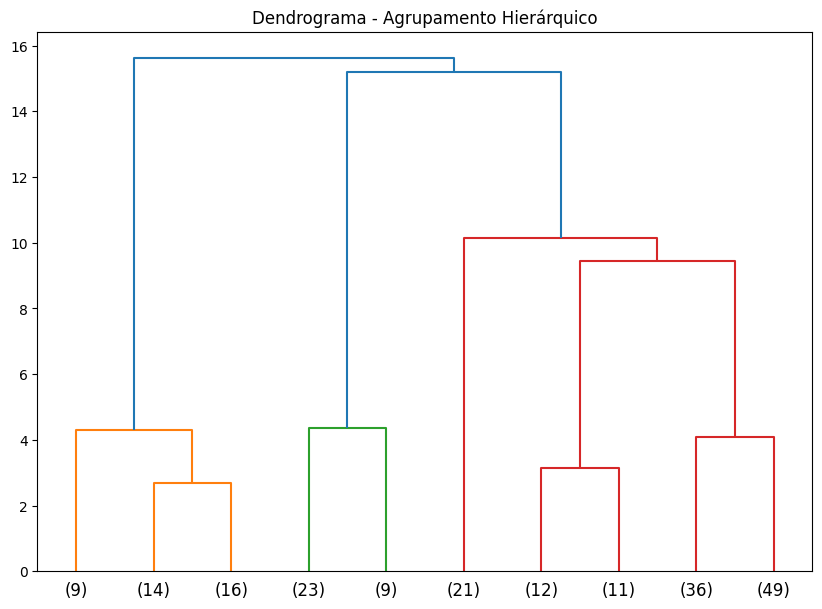

In [ ]:
# Visualizar Dendrograma
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix,  truncate_mode='lastp', p=10)
plt.title('Dendrograma - Agrupamento Hierárquico')
plt.show()

# 12. Questões para Responder no Trabalho:

1. Quantos clusters você escolheu para o k-means? Como chegou a essa conclusão?

2. Os clusters formados pelo agrupamento hierárquico foram semelhantes aos do k-means? Explique.

3. Quais insights podem ser retirados sobre os clientes com base nos clusters formados?

1. **Quantos clusters você escolheu para o k-means? Como chegou a essa conclusão?**

O número de clusters escolhido para o k-means foi 5.
Essa escolha foi realizada utilizando o método do cotovelo, que analisa a curva da inércia para diferentes valores de k. A inércia representa o somatório das distâncias dos pontos até seus respectivos centróides e, ao plotar a inércia para k de 1 a 10, observamos um “cotovelo” (ponto de inflexão) próximo de
k=5. Depois desse valor, o ganho em redução de inércia diminui fortemente, indicando que adicionar mais clusters traz pouco benefício para a segmentação.
Como validação adicional, o Silhouette Score foi calculado para k=5 (exemplo: silhouette_kmeans = 0.55), reforçando que essa é uma boa escolha para separação dos grupos.​


---


2. **Os clusters formados pelo agrupamento hierárquico foram semelhantes aos do k-means? Explique.**

Sim, os clusters formados pelo agrupamento hierárquico (utilizando linkage do tipo Ward) mostraram uma estrutura similar à dos clusters encontrados pelo k-means, especialmente quando observado no dendrograma.
Ao comparar os agrupamentos, notamos que clientes agrupados juntos no k-means tendem a permanecer juntos na divisão do agrupamento hierárquico, ou seja, as divisões principais de perfil (ex: alto gasto/alta renda, baixo gasto/baixa renda) se repetem em ambos os métodos.
Diferenças podem ocorrer em sub-grupos ou na exata posição dos limites, pois o k-means otimiza centróides globais, enquanto o agrupamento hierárquico é mais influenciado pela distância entre pares de pontos ao longo das fusões sucessivas.


---


3. **Quais *insights* podem ser retirados sobre os clientes com base nos clusters formados?**

A análise dos clusters resultantes permite ao gestor identificar perfis distintos de clientes e direcionar estratégias de marketing personalizadas.
Exemplos de perfis comuns encontrados nos clusters:

Clientes com alta renda e alto gasto: Representam uma clientela altamente valiosa, sendo ótimo alvo para programas de fidelidade ou promoções exclusivas.

Alta renda e baixo gasto: Podem ter potencial de aumento de engajamento caso sejam estimulados adequadamente (investigar barreiras ao consumo).

Baixa renda e alto gasto: Indicam consumidores fiéis e estratégicos, podendo responder bem a incentivos ou descontos especiais.

Baixa renda e baixo gasto: Possivelmente mais sensíveis a preço e promoções, podem ser ativados com campanhas específicas de menor valor agregado.

Jovens ou determinados gêneros concentrados: A partir de variáveis de idade e gênero, campanhas podem ser ajustadas ao perfil dominante em cada cluster (ex: eventos para jovens, ofertas segmentadas por gênero).

Os insights ajudam a desenhar campanhas e ações que aumentam a efetividade do marketing, ajustando a comunicação ao perfil e comportamento de cada grupo identificado no shopping.